# Phase 1 :- Importation and Loading the Data

In [2]:
# Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# Loading dataset

df = pd.read_csv('/Users/soujanyaprokashsingha/Documents/Data Analyst_Science/Professional Projects/Datamites Projects/PRCP-1020-House-Price-Prediction/data/raw/data.csv')
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2008,WD,Normal,12.247699
1,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,5,2007,WD,Normal,12.109016
2,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,9,2008,WD,Normal,12.317171
3,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,272,0,0,0,0,2,2006,WD,Abnorml,11.849405
4,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,12,2008,WD,Normal,12.429220


# Phase 2 :- Data Understanding

In [5]:
df.shape

(1456, 76)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1456 entries, 0 to 1455
Data columns (total 76 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1456 non-null   int64  
 1   MSZoning       1456 non-null   object 
 2   LotFrontage    1456 non-null   float64
 3   LotArea        1456 non-null   int64  
 4   Street         1456 non-null   object 
 5   LotShape       1456 non-null   object 
 6   LandContour    1456 non-null   object 
 7   Utilities      1456 non-null   object 
 8   LotConfig      1456 non-null   object 
 9   LandSlope      1456 non-null   object 
 10  Neighborhood   1456 non-null   object 
 11  Condition1     1456 non-null   object 
 12  Condition2     1456 non-null   object 
 13  BldgType       1456 non-null   object 
 14  HouseStyle     1456 non-null   object 
 15  OverallQual    1456 non-null   int64  
 16  OverallCond    1456 non-null   int64  
 17  YearBuilt      1456 non-null   int64  
 18  YearRemo

In [7]:
df.describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.00000,1456.000000,1456.000000,1456.000000,1456.000000,...,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000
mean,56.888736,69.570055,10448.784341,6.088599,5.576236,1971.18544,1984.819368,101.526786,436.991071,46.677198,...,93.833791,46.221154,22.014423,3.418956,15.102335,2.055632,43.608516,6.326236,2007.817308,12.021950
std,42.358363,20.903753,9860.763449,1.369669,1.113966,30.20159,20.652143,177.011773,430.255052,161.522376,...,125.192349,65.352424,61.192248,29.357056,55.828405,35.383772,496.799265,2.698356,1.329394,0.396077
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.00000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,10.460271
25%,20.000000,60.000000,7538.750000,5.000000,5.000000,1954.00000,1966.750000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,11.774528
50%,50.000000,69.000000,9468.500000,6.000000,5.000000,1972.00000,1993.500000,0.000000,381.000000,0.000000,...,0.000000,24.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,12.001512
75%,70.000000,79.000000,11588.000000,7.000000,6.000000,2000.00000,2004.000000,163.250000,706.500000,0.000000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,12.273736
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.00000,2010.000000,1600.000000,2188.000000,1474.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,13.345509


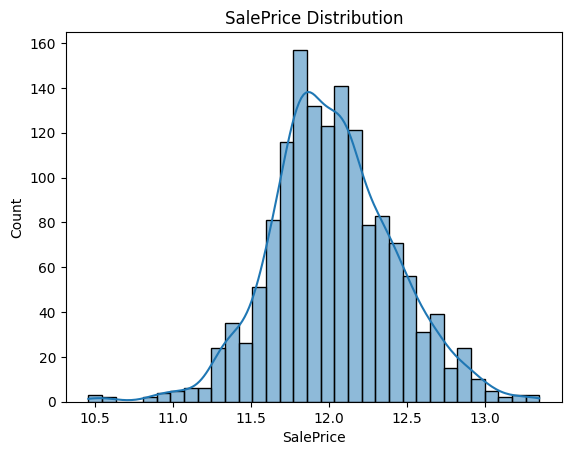

In [8]:
# Checking Target Variable

sns.histplot(df['SalePrice'], kde=True)
plt.title("SalePrice Distribution")
plt.show()

In [9]:
# Checking Missing Values

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing

MasVnrType      871
FireplaceQu     690
GarageType       81
GarageFinish     81
GarageQual       81
GarageCond       81
BsmtExposure     38
BsmtFinType2     38
BsmtQual         37
BsmtCond         37
BsmtFinType1     37
Electrical        1
dtype: int64

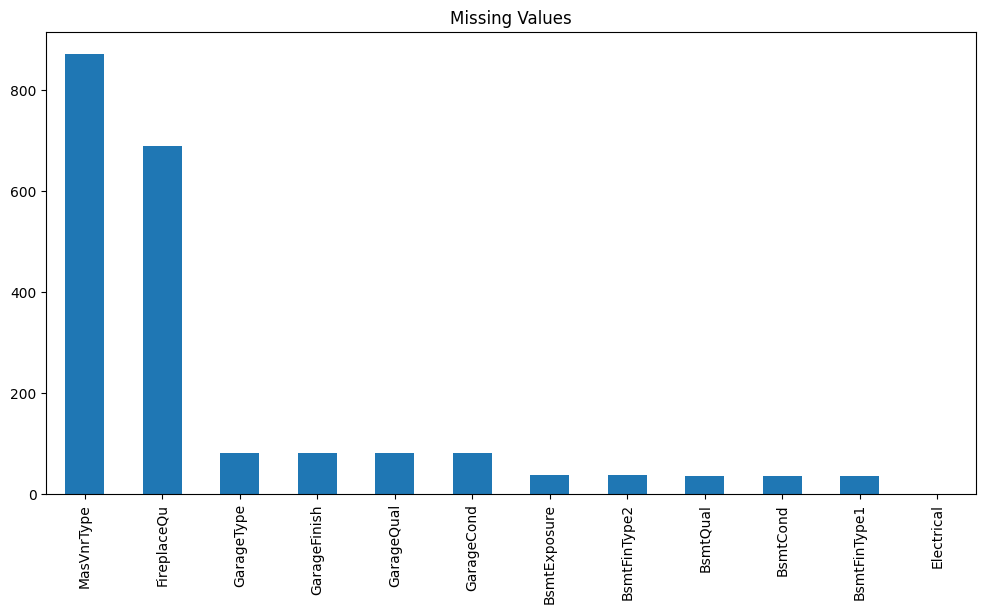

In [10]:
# Visualization of missing values in the dataset

plt.figure(figsize=(12,6))
missing.plot(kind='bar')
plt.title("Missing Values")
plt.show()

In [11]:
# Categorical vs Numerical Features

cat_features = df.select_dtypes(include=['object']).columns
num_features = df.select_dtypes(exclude=['object']).columns

print("Categorical:", len(cat_features))
print("Numerical:", len(num_features))

Categorical: 39
Numerical: 37


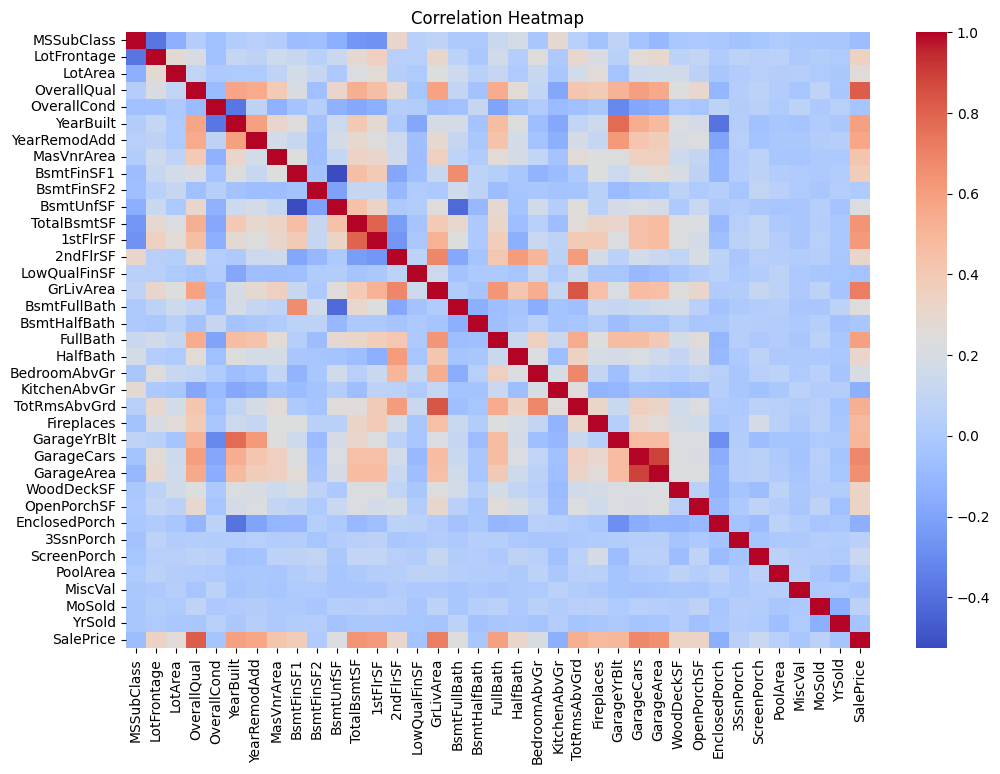

In [12]:
# Correlation Analysis

corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [13]:
corr['SalePrice'].sort_values(ascending=False)

SalePrice        1.000000
OverallQual      0.819240
GrLivArea        0.718844
GarageCars       0.680408
GarageArea       0.655212
TotalBsmtSF      0.641553
1stFlrSF         0.613742
FullBath         0.590919
YearBuilt        0.588977
YearRemodAdd     0.568986
TotRmsAbvGrd     0.533446
GarageYrBlt      0.497659
Fireplaces       0.487126
MasVnrArea       0.425946
BsmtFinSF1       0.382710
LotFrontage      0.342068
WoodDeckSF       0.330573
OpenPorchSF      0.327038
HalfBath         0.311191
2ndFlrSF         0.306605
LotArea          0.258945
BsmtFullBath     0.238851
BsmtUnfSF        0.223248
BedroomAbvGr     0.204117
ScreenPorch      0.123860
MoSold           0.062231
3SsnPorch        0.056065
PoolArea         0.040679
BsmtFinSF2       0.006420
BsmtHalfBath    -0.014974
MiscVal         -0.019752
YrSold          -0.034319
OverallCond     -0.036843
LowQualFinSF    -0.037698
MSSubClass      -0.075083
KitchenAbvGr    -0.147891
EnclosedPorch   -0.148636
Name: SalePrice, dtype: float64

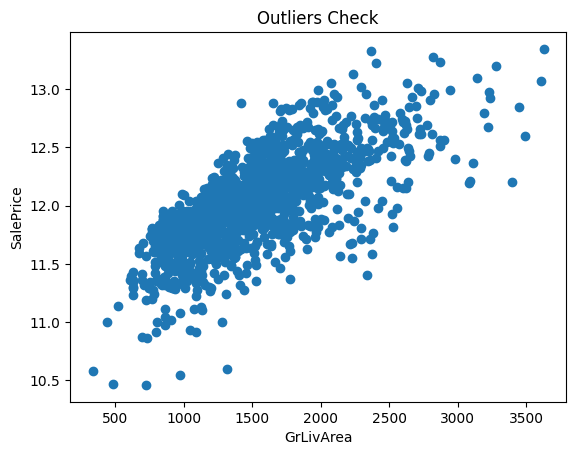

In [14]:
# Checking the Outliers

plt.scatter(df['GrLivArea'], df['SalePrice'])
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.title("Outliers Check")
plt.show()

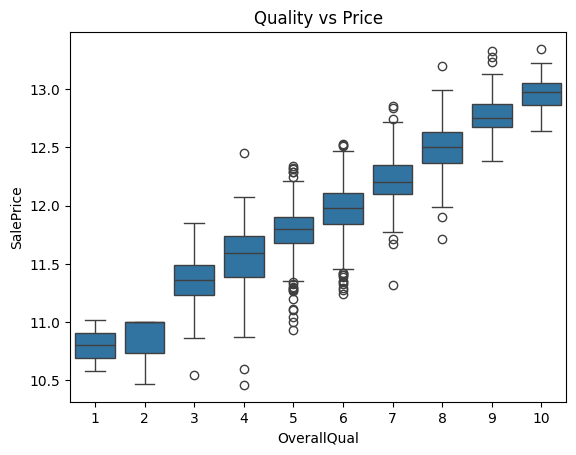

In [15]:
# Univariate Analysis

sns.boxplot(x=df['OverallQual'], y=df['SalePrice'])
plt.title("Quality vs Price")
plt.show()

In [16]:
df.columns

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'WoodDeckSF'

# Phase 3 :- Feature Selection

In [18]:
selected_features = [
    'OverallQual', 'GrLivArea', 'Neighborhood',
    'TotalBsmtSF', 'GarageCars', 'GarageArea',
    'YearBuilt', 'KitchenQual', 'ExterQual',
    'BsmtQual', 'FullBath'
]

target = 'SalePrice'

df = df[selected_features + [target]]

# Phase 4 :- Feature Engineering

In [20]:
df['HouseAge'] = 2024 - df['YearBuilt']

# Drop YearBuilt after creating HouseAge
df.drop('YearBuilt', axis=1, inplace=True)


selected_features.remove('YearBuilt')
selected_features.append('HouseAge')

# Phase 5 :- Preprocessing

In [22]:
# Importation

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [23]:
# Splitting Features

X = df[selected_features]
y = df[target]

In [24]:
# Defining Column Types


num_features = ['GrLivArea', 'TotalBsmtSF', 'GarageCars',
                'GarageArea', 'FullBath', 'HouseAge']

cat_features = ['Neighborhood', 'KitchenQual',
                'ExterQual', 'BsmtQual']

In [25]:
# Column Transfer


preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])


# Phase 6 :- Model Training

In [27]:
# Importation
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import Ridge

In [28]:
# Ridge Model Training


ridge_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1.0))
])

In [29]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [30]:
# Training the Model

ridge_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['GrLivArea', 'TotalBsmtSF',
                                                   'GarageCars', 'GarageArea',
                                                   'FullBath', 'HouseAge']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Neighborhood',
                                                   'KitchenQual', 'ExterQual',
                                                   'BsmtQual'])])),
                ('regressor', Ridge())])

In [31]:
# Gradient Boosting Training

gbr_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(random_state=42))
])

In [32]:
gbr_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['GrLivArea', 'TotalBsmtSF',
                                                   'GarageCars', 'GarageArea',
                                                   'FullBath', 'HouseAge']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Neighborhood',
                                                   'KitchenQual', 'ExterQual',
                                                   'BsmtQual'])])),
                ('regressor', GradientBoostingRegressor(random_state=42))])

In [33]:
# Random Forest Training

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

In [34]:
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['GrLivArea', 'TotalBsmtSF',
                                                   'GarageCars', 'GarageArea',
                                                   'FullBath', 'HouseAge']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Neighborhood',
                                                   'KitchenQual', 'ExterQual',
                                                   'BsmtQual'])])),
                ('regressor', RandomForestRegressor(random_state=42))])

In [35]:
# Predictions

ridge_pred = ridge_model.predict(X_test)
gbr_pred = gbr_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

In [36]:
# Evaluation Functions

def evaluate(y_true, y_pred, name):
    print(f"{name}")
    print("R2 Score:", r2_score(y_true, y_pred))
    print("RMSE:", mean_squared_error(y_true, y_pred, squared=False))
    print("-" * 40)

# Phase 7 :- Comparing all models

In [38]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Ridge", "Gradient Boosting", "Random Forest"],
    "R2 Score": [
        r2_score(y_test, ridge_pred),
        r2_score(y_test, gbr_pred),
        r2_score(y_test, rf_pred)
    ],
    "RMSE": [
        mean_squared_error(y_test, ridge_pred, squared=False),
        mean_squared_error(y_test, gbr_pred, squared=False),
        mean_squared_error(y_test, rf_pred, squared=False)
    ]
})

print(results)

               Model  R2 Score      RMSE
0              Ridge  0.846051  0.155931
1  Gradient Boosting  0.830846  0.163450
2      Random Forest  0.821840  0.167745


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


# Phase 8 :- Saving Model

In [40]:
import joblib
joblib.dump(ridge_model, "house_price_model.pkl")

['house_price_model.pkl']